In [43]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

/var/folders/4t/xvwt6bfj15g6gyg0_t3c2hlm0000gn/T/ipykernel_4089/197913803.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [44]:
load_dotenv()

True

In [45]:
# 1. Simple, clean sample knowledge base strings
faq_policies = [
    "Cancellation Policy: Users can cancel any order within 2 hours of purchase by clicking 'Cancel Order' in their dashboard. After 2 hours, orders enter processing and cannot be manually cancelled.",
    "Refund Policy: Refund requests are accepted within 30 days of product delivery. Items must be unopened and in original packaging.",
    "Shipping Info: Standard shipping takes 3 to 5 business days. Express shipping takes 1 to 2 business days.",
    "Damaged Items: If an item arrives broken, please contact support immediately with photos. We will ship a free replacement."
]

# 2. Set up embeddings and store them locally in FAISS memory
embeddings = OpenAIEmbeddings()
vector_store = FAISS.from_texts(faq_policies, embeddings)

# 3. Turn it into a retriever tool
retriever = vector_store.as_retriever(search_kwargs={"k": 1})

In [46]:
model = ChatOpenAI(model = "gpt-4o-mini")

In [47]:
class ClassifierSchema(BaseModel):
    user_input:str=Field(description="Users query")
    query_type:Literal["simple", "critical"] = Field(..., description="users query type whether it is simple or critical")

In [48]:
structured_model = model.with_structured_output(ClassifierSchema)

In [49]:
prompt1 = "Evaluate the users query for a ecomerce platform and check whether this require human support or company legal data base is enough for this based on that classifiy the users query into simple or critical, user query:\n{user_query}"

In [50]:
class CustomerSupportState(TypedDict):
    user_query: str
    query_type:str
    bot_reply:str

In [54]:
def classify_query(state:CustomerSupportState):
    user_query = state["user_query"]
    prompt1 = "Evaluate the users query for a ecomerce platform and check whether this require human support or company legal data base is enough for this based on that classifiy the users query into simple or critical, user query:\n{user_query}"
    output = structured_model.invoke(prompt1)
    return {"query_type":output.query_type}

def check_query_type(state:CustomerSupportState):
    query_type = state["query_type"]
    if query_type == "simple":
        return "rag_node"
    else:
        return "escalate_node"

def rag_node(state:CustomerSupportState):
    user_query = state["user_query"]

    docs = retriever.invoke(user_query)
    context = docs[0].page_content

    rag_prompt = f"""You are a helpful customer support bot. 
    Answer the user's query using ONLY the provided context below.
    
    Context:
    {context}
    
    User Query: {user_query}
    """

    response = model.invoke(rag_prompt)

    return {"bot_reply": response.content}

def escalate_node(state: CustomerSupportState):
    return {"bot_reply": "Your request requires human assistance. We have logged an escalation ticket for you."}

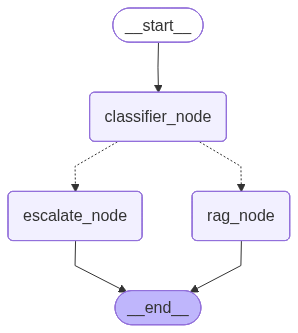

In [58]:
graph = StateGraph(CustomerSupportState)

graph.add_node("classifier_node", classify_query)
graph.add_node("rag_node", rag_node)
graph.add_node("escalate_node", escalate_node)

graph.add_edge(START, "classifier_node")
graph.add_conditional_edges("classifier_node", check_query_type, {
        "rag_node": "rag_node",
        "escalate_node": "escalate_node"
    })
graph.add_edge("rag_node", END)
graph.add_edge("escalate_node", END)

workflow = graph.compile()
workflow

In [57]:
initial_state = {
    "user_query":"how to cancle"
}
res = workflow.invoke(initial_state)
res

{'user_query': 'how to cancle',
 'query_type': 'simple',
 'bot_reply': "You can cancel your order by clicking 'Cancel Order' in your dashboard within 2 hours of purchase. After that time, orders enter processing and cannot be manually cancelled."}